In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# dataset (how you can make your own dataset)
from sklearn.datasets import make_classification

In [3]:
# make_classification seaborn
X,y= make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=20)

In [4]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9
0,-0.772283,0.196706,1.649498,0.471559,0.322462,-0.143971,-0.873637,0.114953,0.754038,1.316466
1,1.466115,-0.569985,-0.490921,-1.170983,1.278384,-0.720606,0.680824,-0.431002,1.054122,-1.378789
2,0.265159,2.354382,-1.302640,0.283290,-0.497433,-1.736997,0.888013,-0.078976,-0.089218,-1.298991
3,1.054882,0.830666,0.012437,-0.435215,-1.780593,1.953013,-1.237963,0.662300,-0.005446,2.381620
4,-0.806635,-0.780728,1.227786,-0.195062,-0.624200,1.051022,-0.099346,0.160575,-0.496138,0.302153
...,...,...,...,...,...,...,...,...,...,...
995,-0.894265,-1.605784,-0.095059,1.710907,1.303194,0.323110,-0.830412,-0.113191,-1.453720,1.021412
996,-0.015521,-0.916188,0.786272,-0.120857,2.091906,0.031402,-0.674116,-0.322670,0.076854,0.590644
997,0.109996,0.155598,0.613506,0.031932,1.957641,0.346085,-0.887701,-0.247003,-0.549994,0.961649
998,0.369745,0.898519,-1.651663,0.554387,-1.226184,-1.243076,-0.687002,0.420673,-0.039926,1.376583


In [5]:
pd.DataFrame(y)

,0
0,1
1,1
2,0
3,0
4,1
...,...
995,1
996,1
997,1
998,0


In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=23)

In [7]:
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression()
logistic.fit(X_train,y_train)
y_pred=logistic.predict(X_test)
print(y_pred)

[1 0 0 0 0 1 1 1 0 0 0 1 1 0 0 0 0 1 0 1 1 1 0 1 0 1 0 1 0 1 1 0 0 1 0 1 1
 1 0 0 1 1 0 0 1 1 0 1 1 1 1 0 1 0 1 1 1 0 1 1 0 1 0 0 1 0 1 0 1 1 0 0 1 1
 1 0 1 0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 1 1 0 1 0 1 1 0 0 1 1 1 0 0 1 0 1 1 1
 0 1 0 1 1 1 1 0 0 0 1 1 0 0 0 0 0 0 0 1 0 1 0 1 0 0 1 0 0 0 1 1 0 0 1 1 0
 0 0 0 1 1 0 0 0 0 1 1 1 0 1 1 0 1 0 1 0 0 1 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1
 0 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 1
 1 0 1 1 1 1 0 1 0 1 1 1 1 1 0 0 0 1 1 1 1 1 0 1 1 1 1 0 0 0 0 1 0 1 0 1 1
 0 1 0 1 0 1 1 0 1 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0 1 0 1 0 1 1 0 1 0 0 1 1 1
 1 1 0 0]


In [8]:
# Performance Metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [9]:
score=accuracy_score(y_pred,y_test)
print(f"Score = {score}")
print(classification_report(y_pred=y_pred,y_true=y_test))
print(confusion_matrix(y_true=y_test,y_pred=y_pred))

Score = 0.9366666666666666
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       138
           1       0.97      0.91      0.94       162

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300

[[133   5]
 [ 14 148]]


## Hyperparameter Tuning And Cross Validation

## Grid SearchCV

In [10]:
model = LogisticRegression()
penalty = ['l1', 'l2', 'elasticnet']
c_values = [100,10,1.0,0.1,0.01]
solver = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']

In [11]:
params= dict(penalty=penalty, C=c_values, solver=solver)
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold()

In [12]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(estimator=model, param_grid=params, scoring='accuracy', n_jobs=-1,cv=cv)

In [13]:
grid

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [100, 10, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbos

In [14]:
grid.fit(X_train,y_train)

c:\Users\codeanddebug\Desktop\AI-ML-Bootcamp\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
225 fits failed out of a total of 450.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\codeanddebug\Desktop\AI-ML-Bootcamp\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\codeanddebug\Desktop\AI-ML-Bootcamp\.venv\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\codeanddebug\Desktop\A

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [100, 10, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbos

In [15]:
grid.best_params_

{'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}

In [16]:
grid.best_score_

np.float64(0.95)

In [17]:
y_pred = grid.predict(X_test)
y_pred

array([1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0])

In [18]:
score=accuracy_score(y_pred,y_test)
print(f"Score = {score}")
print(classification_report(y_pred=y_pred,y_true=y_test))
print(confusion_matrix(y_true=y_test,y_pred=y_pred))

Score = 0.9433333333333334
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       138
           1       0.97      0.93      0.95       162

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300

[[133   5]
 [ 12 150]]


## Randomized Search SV

### GridSearchCV vs RandomizedSearchCV

Both search for the best hyperparameters using cross-validation. The only difference is **which combinations they try**.

| | `GridSearchCV` | `RandomizedSearchCV` |
|---|---|---|
| **Combinations tried** | *Every* combination in the grid (exhaustive) | `n_iter` combinations sampled at random (default `n_iter=10`) |
| **Number of fits** | `n_combinations x cv` | `n_iter x cv` — you control the budget |
| **Parameter values** | Must be explicit lists | Lists **or** distributions, e.g. `scipy.stats.uniform(0.01, 100)` |
| **Guarantee** | Finds the best point *in the grid* | Finds a near-best point with high probability |
| **Reproducible** | Always | Only with `random_state` set |
| **Best when** | Few parameters, small discrete grids | Many parameters, wide/continuous ranges, limited time |

**Our grid:** 5 `C` x 3 `penalty` x 5 `solver` = 75 combinations x 5 folds = **375 fits** for GridSearchCV,
versus 10 x 5 = **50 fits** for RandomizedSearchCV — roughly 7x cheaper for a nearly identical score.

**Why random search usually wins on large grids:** most hyperparameters barely affect the score. Grid search
wastes fits re-testing the unimportant ones at every level of the important ones, while random search samples a
new value for *every* parameter on each draw, so it covers far more distinct values of the parameter that
actually matters (Bergstra & Bengio, 2012).

**Rule of thumb:** use `RandomizedSearchCV` to narrow down a wide range, then `GridSearchCV` to fine-tune the
small region around the winner.

> **Note:** with an invalid grid (e.g. `penalty='l1'` with `solver='lbfgs'`) both fail the same way — the bad
> combinations score `nan` and are silently skipped, so you end up searching far fewer candidates than you think.


In [19]:
from sklearn.model_selection import RandomizedSearchCV

In [20]:
model = LogisticRegression()
random_cv = RandomizedSearchCV(estimator=model, param_distributions=params, cv=cv, scoring="accuracy")

In [21]:
random_cv.fit(X_train,y_train)

c:\Users\codeanddebug\Desktop\AI-ML-Bootcamp\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\codeanddebug\Desktop\AI-ML-Bootcamp\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [100, 10, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot

In [22]:
random_cv.best_params_

{'solver': 'newton-cholesky', 'penalty': 'l2', 'C': 10}

In [23]:
random_cv.best_score_

np.float64(0.9414285714285715)

In [24]:
y_pred = random_cv.predict(X_test)

In [25]:
score=accuracy_score(y_pred,y_test)
print(f"Score = {score}")
print(classification_report(y_pred=y_pred,y_true=y_test))
print(confusion_matrix(y_true=y_test,y_pred=y_pred))

Score = 0.94
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       138
           1       0.97      0.92      0.94       162

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300

[[133   5]
 [ 13 149]]


## Logistic Regression for Multiclass Classification Problem

In [26]:
X, y = make_classification(n_samples=1000, n_features=10, n_informative=3, n_classes=3,random_state=20)
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9
0,-0.924920,-0.073330,0.428465,-0.567368,0.151082,0.736602,0.964168,0.707550,-0.567705,-0.930943
1,1.180709,0.610977,-0.504733,-2.081156,0.418786,-0.260097,4.346283,0.575606,-5.667798,-1.107934
2,-0.901220,-0.279280,-0.324390,0.403991,-0.711649,0.660206,0.804547,1.344125,-0.821208,-0.552676
3,-0.594196,-0.602817,-0.801325,0.973729,-0.628570,1.252127,0.255466,-2.619075,1.874949,-1.736813
4,-1.580901,-1.087377,-1.917434,0.370994,-0.472937,0.561661,0.673465,-2.077217,2.000422,-2.500642
...,...,...,...,...,...,...,...,...,...,...
995,2.060412,0.028138,-0.534654,-0.543475,0.348225,0.166503,1.131609,-0.901255,-2.375112,0.639284
996,-2.091825,1.086735,-1.519429,-0.579451,0.007994,0.919957,0.208097,1.756149,0.561308,-0.999409
997,1.775894,-0.878938,0.080190,0.704591,-0.770947,0.021693,1.662906,-1.505261,-2.277674,-0.126305
998,-1.417548,0.965326,1.997969,0.212007,2.178440,-1.097117,0.874561,-1.968879,1.592471,-2.430783


In [27]:
pd.DataFrame(y)

,0
0,1
1,2
2,1
3,2
4,2
...,...
995,0
996,1
997,0
998,2


In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=23)

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

In [30]:
logistic = OneVsRestClassifier(LogisticRegression())
logistic.fit(X_train,y_train)
y_pred = logistic.predict(X_test)
y_pred

array([0, 0, 0, 0, 2, 1, 2, 1, 2, 0, 1, 1, 2, 2, 1, 1, 0, 0, 2, 1, 2, 1,
       2, 2, 2, 2, 1, 0, 2, 1, 1, 1, 1, 2, 2, 1, 2, 2, 0, 1, 0, 2, 2, 1,
       2, 2, 1, 2, 1, 1, 2, 1, 0, 2, 1, 1, 1, 2, 0, 2, 1, 2, 0, 2, 2, 1,
       2, 1, 0, 2, 1, 2, 0, 1, 1, 0, 2, 0, 0, 0, 2, 2, 2, 1, 1, 2, 2, 1,
       1, 1, 1, 1, 2, 0, 1, 1, 2, 0, 0, 2, 1, 2, 1, 2, 1, 0, 2, 2, 1, 2,
       0, 2, 2, 2, 2, 0, 2, 1, 2, 2, 2, 2, 0, 0, 1, 1, 2, 2, 1, 2, 1, 2,
       2, 1, 0, 1, 1, 0, 0, 1, 2, 1, 2, 1, 0, 2, 0, 2, 1, 0, 1, 0, 2, 1,
       1, 0, 1, 1, 2, 2, 0, 2, 1, 2, 0, 2, 1, 0, 2, 0, 0, 0, 0, 2, 0, 2,
       2, 1, 1, 0, 2, 0, 0, 0, 0, 0, 0, 2, 2, 0, 1, 2, 0, 1, 2, 2, 2, 2,
       1, 1, 0, 0, 1, 0, 2, 2, 2, 0, 1, 1, 2, 0, 1, 1, 1, 1, 1, 2, 0, 2,
       2, 0, 1, 1, 0, 0, 2, 2, 0, 1, 2, 1, 0, 2, 1, 2, 0, 0, 1, 2, 0, 2,
       0, 0, 0, 1, 1, 2, 1, 0, 1, 2, 0, 0, 0, 0, 2, 1, 0, 1, 2, 0, 0, 2,
       2, 0, 0, 2, 2, 0, 0, 1, 0, 0, 1, 0, 2, 2, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 2, 0, 1, 2, 2, 0, 1, 2, 1, 0, 1, 1])

In [31]:
score=accuracy_score(y_pred,y_test)
print(f"Score = {score}")
print(classification_report(y_pred=y_pred,y_true=y_test))
print(confusion_matrix(y_true=y_test,y_pred=y_pred))

Score = 0.7633333333333333
              precision    recall  f1-score   support

           0       0.76      0.77      0.76        94
           1       0.81      0.75      0.78       104
           2       0.72      0.77      0.75       102

    accuracy                           0.76       300
   macro avg       0.77      0.76      0.76       300
weighted avg       0.77      0.76      0.76       300

[[72 10 12]
 [ 8 78 18]
 [15  8 79]]


## Imbalanced Dataset

In [32]:
X , y = make_classification(n_samples=1000,n_features=2,n_clusters_per_class=1, n_redundant=0,weights=[0.99],random_state=20)

In [33]:
pd.DataFrame(X)
pd.DataFrame(y)

,0
0,0
1,0
2,0
3,0
4,0
...,...
995,0
996,0
997,0
998,0


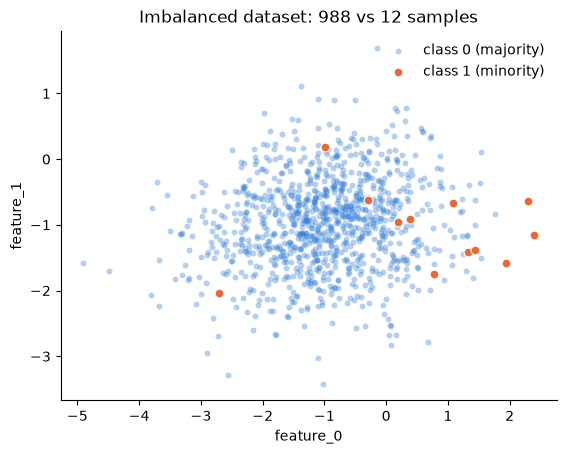

In [34]:
import pandas as pd

# NOTE: seaborn 0.12 made x and y KEYWORD-ONLY. Passing them positionally raises
#   TypeError: scatterplot() takes from 0 to 1 positional arguments but 2 were given
# So `sns.scatterplot(df[0], df[1], hue=y)` must become x=..., y=...

df = pd.DataFrame(X, columns=['feature_0', 'feature_1'])
df['class'] = y

# The dataset is 99:1 imbalanced, so the 100 minority points get buried under the
# 9900 majority points. Draw the majority first and semi-transparent, the minority
# on top with an outline, so the rare class stays visible.
ax = sns.scatterplot(data=df[df['class'] == 0], x='feature_0', y='feature_1',
                     color='#2a78d6', s=18, alpha=0.35, linewidth=0, label='class 0 (majority)')
sns.scatterplot(data=df[df['class'] == 1], x='feature_0', y='feature_1',
                color='#eb6834', s=40, edgecolor='white', linewidth=0.8,
                label='class 1 (minority)', ax=ax)
ax.set_title(f'Imbalanced dataset: {(y==0).sum()} vs {(y==1).sum()} samples')
ax.legend(frameon=False)
sns.despine()

In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=23)

In [36]:
from sklearn.linear_model import LogisticRegression
model= LogisticRegression()
penalty = ['l1', 'l2', 'elasticnet']
c_values = [100,10,1.0,0.1,0.01]
solver = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
class_weight=[{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]
class_weight

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [37]:
params = dict(penalty=penalty,C=c_values,solver=solver,class_weight=class_weight)
params

{'penalty': ['l1', 'l2', 'elasticnet'],
 'C': [100, 10, 1.0, 0.1, 0.01],
 'solver': ['lbfgs',
  'liblinear',
  'newton-cg',
  'newton-cholesky',
  'sag',
  'saga'],
 'class_weight': [{0: 1, 1: 1},
  {0: 1, 1: 10},
  {0: 1, 1: 50},
  {0: 1, 1: 100},
  {0: 10, 1: 1},
  {0: 10, 1: 10},
  {0: 10, 1: 50},
  {0: 10, 1: 100},
  {0: 50, 1: 1},
  {0: 50, 1: 10},
  {0: 50, 1: 50},
  {0: 50, 1: 100},
  {0: 100, 1: 1},
  {0: 100, 1: 10},
  {0: 100, 1: 50},
  {0: 100, 1: 100}]}

In [38]:
from sklearn.model_selection import GridSearchCV,StratifiedKFold

cv = StratifiedKFold()
grid = GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv)

In [39]:
grid.fit(X_train,y_train)

c:\Users\codeanddebug\Desktop\AI-ML-Bootcamp\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\codeanddebug\Desktop\AI-ML-Bootcamp\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [100, 10, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10}, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0

In [40]:
grid.best_params_

{'C': 0.1, 'class_weight': {0: 1, 1: 10}, 'penalty': 'l1', 'solver': 'saga'}

In [41]:
y_pred = grid.predict(X_test)

In [42]:
score=accuracy_score(y_pred,y_test)
print(f"Score = {score}")
print(classification_report(y_pred=y_pred,y_true=y_test))
print(confusion_matrix(y_true=y_test,y_pred=y_pred))

Score = 0.99
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       296
           1       1.00      0.25      0.40         4

    accuracy                           0.99       300
   macro avg       0.99      0.62      0.70       300
weighted avg       0.99      0.99      0.99       300

[[296   0]
 [  3   1]]
